In [1]:
!pip3 install git+https://github.com/NetManAIOps/sktime.git

  Cloning https://github.com/NetManAIOps/sktime.git to /tmp/pip-req-build-i0ytidv_
  Running command git clone --filter=blob:none --quiet https://github.com/NetManAIOps/sktime.git /tmp/pip-req-build-i0ytidv_
  Resolved https://github.com/NetManAIOps/sktime.git to commit c144358adc35b23932db449e3c61e28a33bd133a
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 159.8/159.8 kB 4.7 MB/s eta 0:00:00
  Created wheel for sktime: filename=sktime-0.40.1-py3-none-any.whl size=36374090 sha256=d63ebe2ef481e896c60eb0155a176b6fadd70611b270ed9f6fd463dbc946089a
  Stored in directory: /tmp/pip-ephem-wheel-cache-tlml8vr7/wheels/03/7e/fc/e38659894f6e29738ddf041859f11a018ea4f170d796e6ba4e
Successfully built sktime


In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
rng = np.random.default_rng(7)

# ------------------------------
# 1) Simulate a simple DFM
# ------------------------------
T = 120       # time points (shorter, clearer)
m = 6         # observed series
r = 2         # latent factors

t = np.arange(T)

# Smooth latent factors with tiny noise
f1 = np.sin(2*np.pi*t/24) + 0.05 * rng.normal(size=T)      # 24-step seasonal wave
f2 = np.cos(2*np.pi*t/48) + 0.05 * rng.normal(size=T)      # 48-step slower wave
F_true = np.vstack([f1, f2])                                # r x T

# Loadings (fixed, simple)
Lambda = np.array([
    [ 1.0,  0.4],
    [ 0.8, -0.2],
    [ 0.5,  1.0],
    [-0.6,  0.7],
    [ 0.3, -0.8],
    [-1.0,  0.5],
])  # m x r

# Small idiosyncratic noise
epsilon = 0.2 * rng.normal(size=(m, T))

# Observed data
X = Lambda @ F_true + epsilon  # m x T

# Center
X_mean = X.mean(axis=1, keepdims=True)
Xc = X - X_mean

In [4]:
# ------------------------------
# 2) Estimate factors via PCA (rank-r SVD)
# ------------------------------
U_svd, S_svd, Vt_svd = np.linalg.svd(Xc, full_matrices=False)

U_r = U_svd[:, :r]
S_r = S_svd[:r]
Vt_r = Vt_svd[:r, :]

X_hat = U_r @ np.diag(S_r) @ Vt_r        # common component
F_hat = np.diag(S_r) @ Vt_r              # r x T (up to rotation/scale)

# Align estimated factors to true factors via linear LS: minimize ||F_true - R F_hat||_F
R = F_true @ F_hat.T @ np.linalg.pinv(F_hat @ F_hat.T)
F_hat_aligned = R @ F_hat

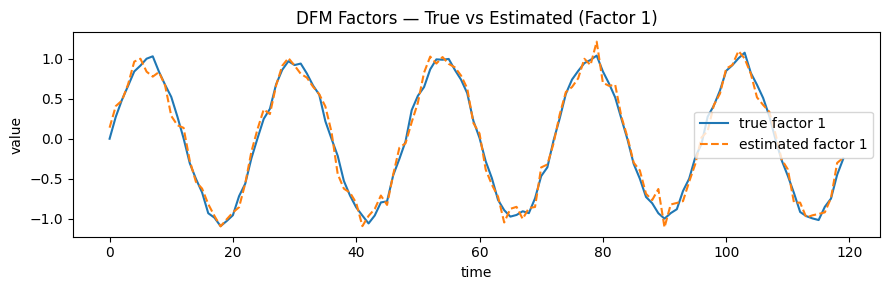

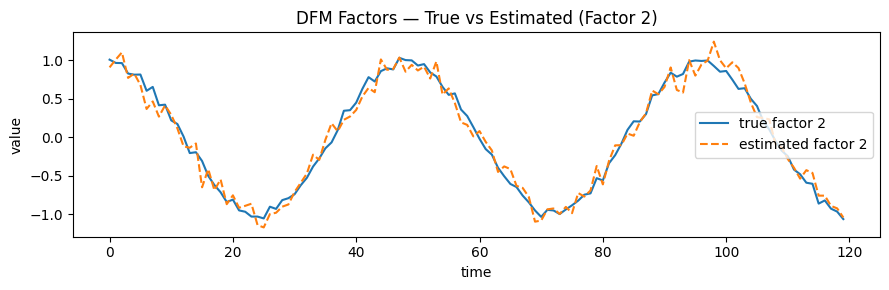

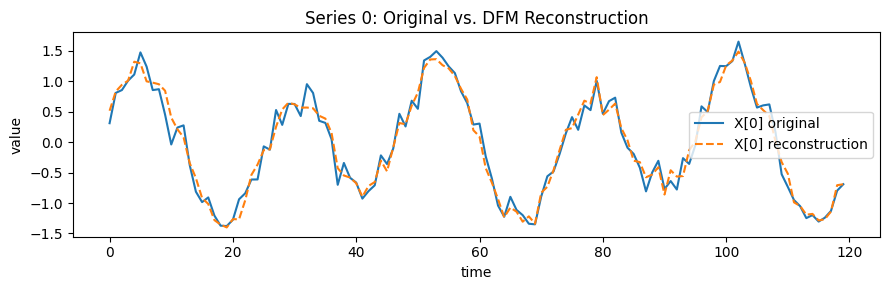

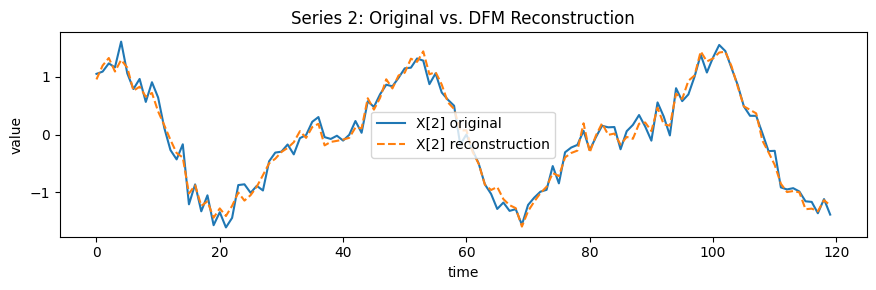

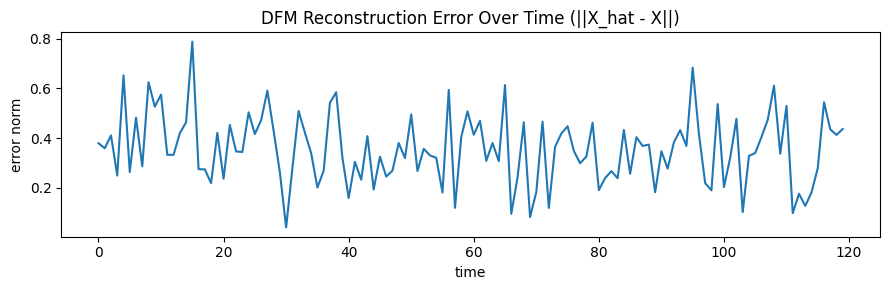

Variance explained by r=2 factors: 0.952


In [5]:
# ------------------------------
# 3) Visualizations (one figure per chart)
# ------------------------------

# (a) Separate plot per factor: true vs estimated-aligned
for i in range(r):
    plt.figure(figsize=(9, 3))
    plt.plot(F_true[i, :], label=f"true factor {i+1}")
    plt.plot(F_hat_aligned[i, :], linestyle="--", label=f"estimated factor {i+1}")
    plt.title(f"DFM Factors — True vs Estimated (Factor {i+1})")
    plt.xlabel("time")
    plt.ylabel("value")
    plt.legend()
    plt.tight_layout()
    plt.show()

# (b) Original vs reconstruction for 2 observed series
for idx in [0, 2]:
    plt.figure(figsize=(9, 3))
    plt.plot(X[idx, :], label=f"X[{idx}] original")
    plt.plot(X_hat[idx, :] + X_mean[idx, 0], linestyle="--", label=f"X[{idx}] reconstruction")
    plt.title(f"Series {idx}: Original vs. DFM Reconstruction")
    plt.xlabel("time")
    plt.ylabel("value")
    plt.legend()
    plt.tight_layout()
    plt.show()

# (c) Reconstruction error over time
err_t = np.linalg.norm((X_hat + X_mean) - X, axis=0)
plt.figure(figsize=(9, 3))
plt.plot(err_t)
plt.title("DFM Reconstruction Error Over Time (||X_hat - X||)")
plt.xlabel("time")
plt.ylabel("error norm")
plt.tight_layout()
plt.show()

# (d) Variance explained
ss_total = np.sum((Xc)**2)
ss_common = np.sum((X_hat)**2)
ve = ss_common / ss_total
print(f"Variance explained by r={r} factors: {ve:.3f}")